-----------------------------------
Number of sites N = 20
Maximum evolution time T = 200
Monte Carlo runs per grid point M = 100
-----------------------------------
In this code we perform a PVM once every tau!
-----------------------------------
Parameters initialized!
State at time = 0 initialized! phi_1 = -0.15707963267948966
phi_1 step number 1/50
State at time = 0 initialized! phi_1 = -0.15066821910073497
phi_1 step number 2/50
State at time = 0 initialized! phi_1 = -0.1442568055219803
phi_1 step number 3/50
State at time = 0 initialized! phi_1 = -0.13784539194322562
phi_1 step number 4/50
State at time = 0 initialized! phi_1 = -0.13143397836447093
phi_1 step number 5/50
State at time = 0 initialized! phi_1 = -0.12502256478571627
phi_1 step number 6/50
State at time = 0 initialized! phi_1 = -0.11861115120696158
phi_1 step number 7/50
State at time = 0 initialized! phi_1 = -0.1121997376282069
phi_1 step number 8/50
State at time = 0 initialized! phi_1 = -0.10578832404945221
phi_1 

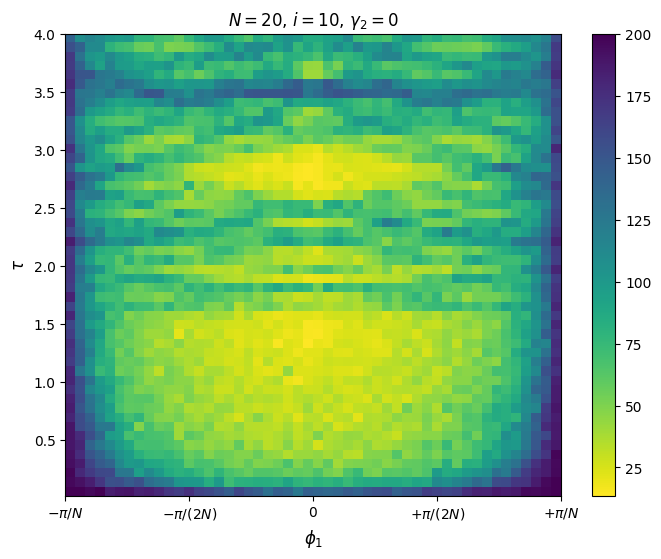

In [ ]:
import numpy as np # for doing stuff with numbers
import matplotlib.pyplot as plt # for plotting
from scipy.linalg import expm # this we need for the time evolution operator
import pandas as pd # to easily print matrices


########################################## PROJECTIVE MEASUREMENT FUNCTION (PVM)

import random
random.seed(13) # for reproducibility

def on_site_PVM(state, target_site):

    # prepare probability to extract outcome and 'blank' state to write the result
    prob_success = np.abs(state[target_site]) ** 2 # this is |<i|psi>|^2
    collapsed_state = np.zeros_like(state) # that is, np.zeros(len(psi), dtype=psi.dtype)
    detection_successful = False

    if (random.random()>=prob_success):
        # print(rf"Walker is NOT at site {target_site}.")
        # projecting on the complementary subspace
        collapsed_state = state.copy()
        collapsed_state[target_site] = 0.0 
        # renormalize
        norm = np.linalg.norm(collapsed_state)
        if norm > 0:
            collapsed_state = collapsed_state/norm
    else:
        #print(rf"Success! Walker at site {target_site}.")
        collapsed_state[target_site] = state[target_site] / np.sqrt(prob_success)
        detection_successful = True

    return collapsed_state, detection_successful


########################################## FUNCTION TO SHOW GRAPHS 

def plot_graph_from_Hamiltonian(matrix):

    import networkx as nx # to make a picture of the graph structure... (don't wanna leave connectivity unchecked)
    G = nx.Graph()
    num_sites = matrix.shape[0]
    # define sites
    for i in range(num_sites):
        G.add_node(i)
    # find and add edges
    for i in range(num_sites):
        for j in range(i+1, num_sites):
            if np.abs(matrix[i,j]) > 1e-12:
                G.add_edge(i,j)

    pos = nx.circular_layout(G)
    plt.figure(figsize=(7,7))

    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=600, edge_color='navy', alpha=0.8)
    plt.title(rf"Graph Structure for H")


####################################################################################
####################################################################################
#################################################################################### MAIN CODE
####################################################################################
####################################################################################

####################################################################################
# IDEA: mean hitting times over a 2D grid of tau vs phi_1 for a fixed size N
####################################################################################

##########################################
# 1. define parameters for a qw on a line
##########################################

# test different phis and taus (2D GRID) for fixed size N
num_sites = 20
target_site = num_sites // 2 # opposite end
num_phi_points = 200 # horizontal resolution
num_tau_points = 200 # vertical resolution
phi_min = -np.pi/num_sites
phi_max = +np.pi/num_sites
tau_min = 0.02
tau_max = 4.00
# time evolution parameters and number of MC runs
T_max = 200 # cutoff time (limited resource)
M = 200 # number of samples of the hitting time

print(rf'-----------------------------------')
print(rf'Number of sites N = {num_sites}')
print(rf'Maximum evolution time T = {T_max}')
print(rf'Monte Carlo runs per grid point M = {M}')
print(rf'-----------------------------------')
print(rf'In this code we perform a PVM once every tau!')
print(rf'-----------------------------------')

# couplings and constants relevant to H
on_site_energy = 0.0
gamma = 1.0 # hopping rate
gamma_1 = 1.0
gamma_2 = 0.0
#phi_1 = 0.0
phi_2 = 0.0
#phase_1 = np.exp(1j * phi_1)
phase_2 = np.exp(1j * phi_2)

# start constructing the grid by defining the 'checkerboard'...
phi_values = np.linspace(phi_min, phi_max, num_phi_points)
tau_values = np.linspace(tau_min, tau_max, num_tau_points)
# ...and setting all values to zero
mean_hitting_times = np.zeros((num_tau_points, num_phi_points))

print(rf'Parameters initialized!')
print(rf'===================================')

for p_idx, phi_1 in enumerate(phi_values): # the first variable is the index, the second the value

    phase_1 = np.exp(1j * phi_1)

    ##########################################
    # 2. Laplacian matrix for a ring (L = D - A)
    ##########################################

    # on-site energies
    diag = 2 * np.eye(num_sites) * on_site_energy

    # first neighbor hopping
    first_n_upper = -gamma_1 * np.eye(num_sites, k=1) * phase_1
    first_n_lower = -gamma_1 * np.eye(num_sites, k=-1) * np.conjugate(phase_1)
    second_n_upper = -gamma_2 * np.eye(num_sites, k=2) * phase_2
    second_n_lower = -gamma_2 * np.eye(num_sites, k=-2) * np.conjugate(phase_2)

    # sum
    L = diag + first_n_upper + first_n_lower + second_n_upper + second_n_lower

    # add periodic boundary conditions (it becomes a ring...)
    L += -gamma_1*(np.eye(num_sites, k=(num_sites-1))+np.eye(num_sites, k=-(num_sites-1)))
    L += -gamma_2*(np.eye(num_sites, k=(num_sites-2))+np.eye(num_sites, k=-(num_sites-2)))

    ##########################################
    # 3. initialization of the state
    ##########################################

    psi_0 = np.zeros(num_sites, dtype=complex)
    psi_0[0] = 1.0 # start at node 0
   
    print(rf'State at time = 0 initialized! phi_1 = {phi_1}')

    ##########################################
    # 4. time evolution (time-indep. H) without PVM
    ##########################################

    H = gamma * L

    for t_idx, tau in enumerate(tau_values):

        U_tau = expm(-1j * H * tau) # coherent unitary evolution step 
        total_hitting_time = 0.0

        # MC loop to get an average estimate of the time it takes to first measure
        for run in range(M):
            psi_step = psi_0.copy()
            time = 0.0
            detected = False

            while (not detected) and time < T_max:
                psi_step = np.dot(U_tau, psi_step) # whole tau long unitary step
                time += tau
                psi_step, detected = on_site_PVM(psi_step, target_site) # attempt to measure

            total_hitting_time += time

        mean_hitting_times[t_idx, p_idx] = total_hitting_time / M # mean

    print(rf'phi_1 step number {p_idx + 1}/{num_phi_points}')

print(rf'===================================')
print(rf'All simulations completed!')
print(rf'===================================')

##########################################
# 5. plot of the 2d mean hitting time grid
##########################################

plt.figure(figsize=(8,6))
extent = [phi_min, phi_max, tau_min, tau_max]

im = plt.imshow(
    mean_hitting_times, 
    extent=extent, 
    origin='lower', 
    aspect='auto', 
    cmap='viridis_r'
)

fonts = 12
plt.xlabel(rf'$\phi_1$', fontsize = fonts)
plt.ylabel(rf'$\tau$', fontsize = fonts)
plt.title(rf'$N = {num_sites}$, $i={target_site}$, $\gamma_2 = 0$', fontsize = fonts)

ticks = [-np.pi/num_sites, -0.5*np.pi/num_sites, 0, 0.5*np.pi/num_sites , np.pi/num_sites]
tick_labels = [rf'$-\pi/N$', rf'$-\pi/(2N)$', rf'$0$', rf'$+\pi/(2N)$', rf'$+\pi/N$']
plt.xticks(ticks, tick_labels)

cbar = plt.colorbar(im)
filename = rf'phi1_vs_tau_mean_hitting_time_PVM_gamma2_{gamma_2}_N_{num_sites}_resolution_{num_phi_points}x{num_tau_points}'
plt.savefig(filename+'.pdf')
plt.show()

##########################################
# 6. find shortest time and associated parameters
##########################################

min_time = np.min(mean_hitting_times)
min_tau_idx, min_phi_idx = np.unravel_index(np.argmin(mean_hitting_times), mean_hitting_times.shape)

optimal_tau_val = tau_values[min_tau_idx]
optimal_phi_val = phi_values[min_phi_idx]

data_filename = filename+'.txt'
with open(data_filename, 'w') as f:
    f.write(rf"Minimum mean hitting time to site {target_site}: {min_time}\n")
    f.write(rf"Number of Monte Carlo runs per point M: {M}\n")
    f.write(rf"Optimal parameters: \phi_1 = {optimal_phi_val}, \tau = {optimal_tau_val}\n")
    